# 18. Chimera Composite Spectra

This notebook rebuilds a composite spectrum from scratch for one Chimera object. It reads `chimera_provenance.csv`, finds the matching COSMOS/zCOSMOS galaxy spectrum and DR7Q AGN spectrum, standardizes wavelength and flux-density units, shifts the spectra onto the Chimera redshift frame, applies COSMOS foreground extinction, and combines them as

`F_lambda,composite = F_lambda,galaxy + chimera_qso_weight * F_lambda,qso`.

Important logic note: spectra are naturally stored as flux density (`erg cm^-2 s^-1 Angstrom^-1`). We should sum the components in flux-density units after putting them on the same observed-frame wavelength grid. A per-bin integrated flux can then be computed as `F_lambda * delta_lambda`; converting to integrated flux before interpolation can create binning-dependent artifacts.

## Imports And Plot Style

Load the standard-library tools, Astropy FITS reader, NumPy, and Matplotlib. The notebook avoids pandas so it can run in the current project environment.

In [30]:
from pathlib import Path
import csv
import os
import re
import warnings

PROJECT_ROOT_FOR_MPL = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
MPLCONFIGDIR = PROJECT_ROOT_FOR_MPL / "notebook_outputs" / "18_chimera_composite_spectra" / "mplconfig"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import numpy as np
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

## Configuration

Choose the Chimera object and define the data paths. Leave `CHIMERA_ID = None` to use the matched default below, or set it to a specific `chimera_id` from `chimera_provenance.csv`.

In [31]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / "data"

PROVENANCE_CSV = PROJECT_ROOT / "chimera_provenance.csv"
COSMOS_FITS = DATA_DIR / "COSMOS2015_Laigle+_v1.1.fits"
DR7Q_SPECTRA_DIR = DATA_DIR / "dr7q_spectra"

# Galaxy spectra may live in zCOSMOS or CESAM/VUDS-style folders.
GALAXY_SPECTRA_DIRS = [
    DATA_DIR / "zCOSMOS_data",
    DATA_DIR / "zCOSMOS selected",
    DATA_DIR / "cesam_vudz",
    DATA_DIR / "cesam_vuds",
]

OUTPUT_DIR = PROJECT_ROOT / "notebook_outputs" / "18_chimera_composite_spectra"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# This default is the first provenance row I found with both a local zCOSMOS galaxy spectrum
# and a local DR7Q FITS spectrum. Set to None only after adding broader auto-selection logic.
CHIMERA_ID = "165523.09+184708.4_701398_0.01"

# Set this to True if you explicitly want rest-frame output instead of the target observed frame.
MAKE_REST_FRAME_PRODUCTS = True

# The zCOSMOS spectrum is already the actual galaxy at the Chimera redshift; this switch exists
# for auditability if you want to force a redshift operation on both components.
GALAXY_SOURCE_REDSHIFT_USES_CHIMERA = True

print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: /home/nicho/GRAHSP/grahspj
Output directory: /home/nicho/GRAHSP/grahspj/notebook_outputs/18_chimera_composite_spectra


## Provenance Lookup

Open `chimera_provenance.csv`, select the object, and pull out the COSMOS galaxy ID, DR7Q spectrum key, Chimera redshift, DR7Q redshift, and QSO weight.

In [32]:
def load_provenance(path):
    with path.open(newline="") as handle:
        return list(csv.DictReader(handle))

provenance_rows = load_provenance(PROVENANCE_CSV)
if not provenance_rows:
    raise ValueError(f"No rows found in {PROVENANCE_CSV}")

if CHIMERA_ID is None:
    provenance = provenance_rows[0]
else:
    matches = [row for row in provenance_rows if row["chimera_id"] == CHIMERA_ID]
    if not matches:
        raise ValueError(f"Could not find CHIMERA_ID={CHIMERA_ID!r} in {PROVENANCE_CSV}")
    provenance = matches[0]

chimera_id = provenance["chimera_id"]
cosmos_id = int(provenance["cosmos_id"])
dr7q_plate = int(provenance["dr7q_plate"])
dr7q_mjd = int(provenance["dr7q_mjd"])
dr7q_fiber = int(provenance["dr7q_fiber"])
chimera_redshift = float(provenance["chimera_redshift"])
dr7q_redshift = float(provenance["dr7q_redshift"])
qso_weight = float(provenance["chimera_qso_weight"])

print(f"Chimera ID: {chimera_id}")
print(f"COSMOS ID: {cosmos_id}")
print(f"DR7Q spectrum: plate={dr7q_plate}, mjd={dr7q_mjd}, fiber={dr7q_fiber}")
print(f"z_chimera={chimera_redshift:.6f}, z_dr7q={dr7q_redshift:.6f}, qso_weight={qso_weight:g}")

Chimera ID: 165523.09+184708.4_701398_0.01
COSMOS ID: 701398
DR7Q spectrum: plate=1568, mjd=53169, fiber=14
z_chimera=3.329000, z_dr7q=3.323000, qso_weight=0.01


## COSMOS Foreground Metadata

Read the COSMOS catalogue row for the selected galaxy. The `EBV` value is used as the COSMOS foreground color excess for the synthetic Chimera line of sight.

In [33]:
def find_cosmos_row(path, object_id):
    with fits.open(path, memmap=True) as hdul:
        data = hdul[1].data
        matches = np.flatnonzero(np.asarray(data["NUMBER"]) == object_id)
        if len(matches) != 1:
            raise ValueError(f"Expected one COSMOS2015 row for NUMBER={object_id}, found {len(matches)}")
        row = data[matches[0]]
        return {name: row[name] for name in data.names}

cosmos_row = find_cosmos_row(COSMOS_FITS, cosmos_id)
cosmos_ebv = float(cosmos_row.get("EBV", 0.0))
cosmos_ra = float(cosmos_row.get("ALPHA_J2000", np.nan))
cosmos_dec = float(cosmos_row.get("DELTA_J2000", np.nan))

print(f"COSMOS EBV: {cosmos_ebv:.5f}")
print(f"COSMOS position: RA={cosmos_ra:.6f}, Dec={cosmos_dec:.6f}")

COSMOS EBV: 0.01893
COSMOS position: RA=149.916968, Dec=2.363725


## Spectrum File Matching

Build an index from COSMOS/zCOSMOS object IDs to FITS files, then find the DR7Q spectrum using the plate-MJD-fiber key. The zCOSMOS index uses both FITS headers and ESO readme mappings because the archive filenames do not always contain the COSMOS ID.

In [34]:
def clean_fits_text(value):
    if isinstance(value, bytes):
        value = value.decode("utf-8", errors="ignore")
    return str(value).strip()


def parse_zcosmos_readme_mappings(directory):
    mapping = {}
    for readme in directory.glob("readme*.txt"):
        text = readme.read_text(errors="ignore")
        for archive_name, original_name in re.findall(r"-\s+(ADP[^\s]+\.fits)\s+(zCOSMOS[^\s]+\.fits)", text):
            match = re.search(r"_(\d{6,9})_", original_name)
            if not match:
                continue
            object_id = int(match.group(1))
            archive_path = directory / archive_name.replace(":", "_")
            if archive_path.exists():
                mapping.setdefault(object_id, []).append(archive_path)
    return mapping


def build_galaxy_spectrum_index(directories):
    index = {}
    diagnostics = []
    for directory in directories:
        if not directory.exists():
            diagnostics.append((directory, "missing directory"))
            continue

        for object_id, paths in parse_zcosmos_readme_mappings(directory).items():
            index.setdefault(object_id, []).extend(paths)

        for path in sorted(directory.glob("*.fits")):
            if path.name.endswith(":Zone.Identifier"):
                continue
            try:
                with fits.open(path, memmap=True) as hdul:
                    header_candidates = [hdul[0].header, hdul[1].header if len(hdul) > 1 else hdul[0].header]
                    ids = []
                    for header in header_candidates:
                        for key in ("OBJECT", "ORIGFILE", "TITLE"):
                            if key in header:
                                ids.extend(int(value) for value in re.findall(r"\d{6,9}", clean_fits_text(header[key])))
                    for object_id in ids:
                        index.setdefault(object_id, []).append(path)
            except Exception as exc:
                diagnostics.append((path, f"could not inspect: {exc}"))

    deduped = {}
    for object_id, paths in index.items():
        seen = []
        for path in paths:
            if path not in seen:
                seen.append(path)
        deduped[object_id] = seen
    return deduped, diagnostics


def find_dr7q_spectrum(directory, plate, mjd, fiber):
    candidates = [
        directory / f"spec-{plate:04d}-{mjd}-{fiber:04d}.fits",
        directory / f"spec-{plate}-{mjd}-{fiber}.fits",
        directory / f"spec-{plate:04d}-{mjd}-{fiber:03d}.fits",
    ]
    for path in candidates:
        if path.exists():
            return path
    globbed = sorted(directory.glob(f"spec-{plate:04d}-{mjd}-*.fits")) + sorted(directory.glob(f"spec-{plate}-{mjd}-*.fits"))
    fiber_tokens = {f"-{fiber:04d}.fits", f"-{fiber:03d}.fits", f"-{fiber}.fits"}
    for path in globbed:
        if any(path.name.endswith(token) for token in fiber_tokens):
            return path
    raise FileNotFoundError(f"Could not find DR7Q spectrum for {plate}-{mjd}-{fiber} in {directory}")

galaxy_index, galaxy_index_diagnostics = build_galaxy_spectrum_index(GALAXY_SPECTRA_DIRS)
galaxy_paths = galaxy_index.get(cosmos_id, [])
if not galaxy_paths:
    raise FileNotFoundError(
        f"Could not find a galaxy spectrum for COSMOS ID {cosmos_id}. "
        "Check zCOSMOS/CESAM-VUDS folders or add a direct file path."
    )

galaxy_spectrum_path = galaxy_paths[0]
dr7q_spectrum_path = find_dr7q_spectrum(DR7Q_SPECTRA_DIR, dr7q_plate, dr7q_mjd, dr7q_fiber)

print(f"Galaxy spectrum: {galaxy_spectrum_path}")
print(f"Additional galaxy candidates: {len(galaxy_paths) - 1}")
print(f"DR7Q spectrum: {dr7q_spectrum_path}")
missing_dirs = [str(path) for path, message in galaxy_index_diagnostics if message == "missing directory"]
if missing_dirs:
    print("Missing optional galaxy-spectrum directories:", missing_dirs)

Galaxy spectrum: /home/nicho/GRAHSP/grahspj/data/zCOSMOS_data/ADP.2015-10-15T12_53_10.333.fits
Additional galaxy candidates: 0
DR7Q spectrum: /home/nicho/GRAHSP/grahspj/data/dr7q_spectra/spec-1568-53169-0014.fits
Missing optional galaxy-spectrum directories: ['/home/nicho/GRAHSP/grahspj/data/cesam_vudz', '/home/nicho/GRAHSP/grahspj/data/cesam_vuds']


## Wavelength And Flux Helpers

Define readers that convert any logarithmic SDSS wavelength grid into Angstrom, put SDSS flux density into `erg cm^-2 s^-1 Angstrom^-1`, and keep zCOSMOS flux density in its native physical units.

In [35]:
def finite_sorted_spectrum(wavelength, flux_density, error=None):
    wavelength = np.asarray(wavelength, dtype=float)
    flux_density = np.asarray(flux_density, dtype=float)
    if error is None:
        error = np.full_like(flux_density, np.nan, dtype=float)
    else:
        error = np.asarray(error, dtype=float)

    valid = np.isfinite(wavelength) & np.isfinite(flux_density) & (wavelength > 0)
    wavelength = wavelength[valid]
    flux_density = flux_density[valid]
    error = error[valid]
    order = np.argsort(wavelength)
    return wavelength[order], flux_density[order], error[order]


def load_zcosmos_spectrum(path):
    with fits.open(path, memmap=True) as hdul:
        row = hdul[1].data[0]
        wave = np.asarray(row["WAVE"], dtype=float)
        flux = np.asarray(row["FLUX_REDUCED"], dtype=float)
        err = np.asarray(row["ERR"], dtype=float) if "ERR" in hdul[1].data.names else None
        header = dict(hdul[0].header)
        ext_header = dict(hdul[1].header)
    wave, flux, err = finite_sorted_spectrum(wave, flux, err)
    return {
        "label": "galaxy",
        "path": Path(path),
        "wavelength_obs_angstrom": wave,
        "flux_density_obs": flux,
        "flux_density_err_obs": err,
        "source_redshift": chimera_redshift if GALAXY_SOURCE_REDSHIFT_USES_CHIMERA else float(header.get("SPEC_Z", chimera_redshift)),
        "unit": "erg cm^-2 s^-1 Angstrom^-1",
        "header": header,
        "ext_header": ext_header,
    }


def load_sdss_dr7q_spectrum(path):
    with fits.open(path, memmap=True) as hdul:
        coadd = hdul[1].data
        names = set(coadd.names)
        if "loglam" in names:
            wave = 10.0 ** np.asarray(coadd["loglam"], dtype=float)
            wavelength_note = "Converted SDSS loglam to wavelength in Angstrom."
        elif "lambda" in names:
            wave = np.asarray(coadd["lambda"], dtype=float)
            wavelength_note = "Read SDSS wavelength column directly."
        else:
            raise KeyError(f"No wavelength/loglam column found in {path}")

        flux = np.asarray(coadd["flux"], dtype=float) * 1e-17
        if "ivar" in names:
            ivar = np.asarray(coadd["ivar"], dtype=float)
            err = np.full_like(flux, np.nan, dtype=float)
            good_ivar = ivar > 0
            err[good_ivar] = 1.0 / np.sqrt(ivar[good_ivar]) * 1e-17
        else:
            err = None
        header = dict(hdul[0].header)
    wave, flux, err = finite_sorted_spectrum(wave, flux, err)
    return {
        "label": "qso",
        "path": Path(path),
        "wavelength_obs_angstrom": wave,
        "flux_density_obs": flux,
        "flux_density_err_obs": err,
        "source_redshift": dr7q_redshift,
        "unit": "erg cm^-2 s^-1 Angstrom^-1",
        "wavelength_note": wavelength_note,
        "header": header,
    }

galaxy_spec = load_zcosmos_spectrum(galaxy_spectrum_path)
qso_spec = load_sdss_dr7q_spectrum(dr7q_spectrum_path)

print(f"Galaxy points: {len(galaxy_spec['wavelength_obs_angstrom'])}; unit={galaxy_spec['unit']}")
print(f"QSO points: {len(qso_spec['wavelength_obs_angstrom'])}; unit={qso_spec['unit']}")
print(qso_spec["wavelength_note"])

Galaxy points: 1642; unit=erg cm^-2 s^-1 Angstrom^-1
QSO points: 3836; unit=erg cm^-2 s^-1 Angstrom^-1
Converted SDSS loglam to wavelength in Angstrom.


## Redshift Adjustment

Shift each spectrum through rest frame and back to the Chimera observed frame. For flux density, the transformation is `lambda_rest = lambda_obs / (1 + z_source)` and `F_lambda_rest = F_lambda_obs * (1 + z_source)`, then `F_lambda_target_obs = F_lambda_rest / (1 + z_chimera)`.

In [36]:
def shift_flux_density_to_redshift(spec, target_redshift):
    z_source = float(spec["source_redshift"])
    wave_obs = spec["wavelength_obs_angstrom"]
    flux_obs = spec["flux_density_obs"]
    err_obs = spec["flux_density_err_obs"]

    wave_rest = wave_obs / (1.0 + z_source)
    flux_rest = flux_obs * (1.0 + z_source)
    err_rest = err_obs * (1.0 + z_source)

    wave_target = wave_rest * (1.0 + target_redshift)
    flux_target = flux_rest / (1.0 + target_redshift)
    err_target = err_rest / (1.0 + target_redshift)

    out = dict(spec)
    out.update({
        "wavelength_rest_angstrom": wave_rest,
        "flux_density_rest": flux_rest,
        "flux_density_err_rest": err_rest,
        "wavelength_target_obs_angstrom": wave_target,
        "flux_density_target_obs": flux_target,
        "flux_density_err_target_obs": err_target,
        "target_redshift": target_redshift,
    })
    return out

galaxy_shifted = shift_flux_density_to_redshift(galaxy_spec, chimera_redshift)
qso_shifted = shift_flux_density_to_redshift(qso_spec, chimera_redshift)

for spec in [galaxy_shifted, qso_shifted]:
    print(
        f"{spec['label']}: z_source={spec['source_redshift']:.6f} -> z_target={spec['target_redshift']:.6f}; "
        f"lambda range {np.nanmin(spec['wavelength_target_obs_angstrom']):.1f}-{np.nanmax(spec['wavelength_target_obs_angstrom']):.1f} Angstrom"
    )

galaxy: z_source=3.329000 -> z_target=3.329000; lambda range 5505.1-9694.6 Angstrom
qso: z_source=3.323000 -> z_target=3.329000; lambda range 3815.9-9227.9 Angstrom


## COSMOS Foreground Extinction

Apply a wavelength-dependent Milky Way foreground attenuation using the COSMOS `EBV` value. This creates a synthetic observed Chimera spectrum along the COSMOS line of sight. It is not a dereddening step; if you want intrinsic spectra, set `apply=False` below.

In [37]:
def ccm89_a_lambda_over_av(wavelength_angstrom, rv=3.1):
    # Cardelli, Clayton & Mathis (1989) optical/IR/UV extinction curve.
    wave_micron = np.asarray(wavelength_angstrom, dtype=float) / 1e4
    x = 1.0 / wave_micron
    a = np.zeros_like(x, dtype=float)
    b = np.zeros_like(x, dtype=float)

    ir = (x >= 0.3) & (x < 1.1)
    a[ir] = 0.574 * x[ir] ** 1.61
    b[ir] = -0.527 * x[ir] ** 1.61

    opt = (x >= 1.1) & (x < 3.3)
    y = x[opt] - 1.82
    a[opt] = 1 + 0.17699*y - 0.50447*y**2 - 0.02427*y**3 + 0.72085*y**4 + 0.01979*y**5 - 0.77530*y**6 + 0.32999*y**7
    b[opt] = 1.41338*y + 2.28305*y**2 + 1.07233*y**3 - 5.38434*y**4 - 0.62251*y**5 + 5.30260*y**6 - 2.09002*y**7

    uv = (x >= 3.3) & (x <= 8.0)
    fa = np.zeros_like(x[uv])
    fb = np.zeros_like(x[uv])
    high = x[uv] >= 5.9
    fa[high] = -0.04473 * (x[uv][high] - 5.9) ** 2 - 0.009779 * (x[uv][high] - 5.9) ** 3
    fb[high] = 0.2130 * (x[uv][high] - 5.9) ** 2 + 0.1207 * (x[uv][high] - 5.9) ** 3
    a[uv] = 1.752 - 0.316*x[uv] - 0.104 / ((x[uv] - 4.67)**2 + 0.341) + fa
    b[uv] = -3.090 + 1.825*x[uv] + 1.206 / ((x[uv] - 4.62)**2 + 0.263) + fb

    outside = ~(ir | opt | uv)
    if np.any(outside):
        warnings.warn("Some wavelengths are outside the CCM89 0.125-3.33 micron range; extinction set to NaN there.")
        a[outside] = np.nan
        b[outside] = np.nan
    return a + b / rv


def apply_foreground_extinction(wavelength_angstrom, flux_density, ebv, rv=3.1, apply=True):
    if not apply:
        return np.asarray(flux_density, dtype=float), np.zeros_like(np.asarray(flux_density, dtype=float))
    a_over_av = ccm89_a_lambda_over_av(wavelength_angstrom, rv=rv)
    a_lambda = a_over_av * rv * ebv
    attenuation = 10.0 ** (-0.4 * a_lambda)
    return np.asarray(flux_density, dtype=float) * attenuation, a_lambda

APPLY_COSMOS_FOREGROUND_EXTINCTION = True

for spec in [galaxy_shifted, qso_shifted]:
    attenuated, a_lambda = apply_foreground_extinction(
        spec["wavelength_target_obs_angstrom"],
        spec["flux_density_target_obs"],
        cosmos_ebv,
        apply=APPLY_COSMOS_FOREGROUND_EXTINCTION,
    )
    spec["flux_density_extincted"] = attenuated
    spec["a_lambda_cosmos_mag"] = a_lambda
    print(f"{spec['label']}: median A_lambda={np.nanmedian(a_lambda):.4f} mag")

galaxy: median A_lambda=0.0386 mag
qso: median A_lambda=0.0539 mag


## Common Wavelength Grid

Create an observed-frame grid over the overlapping wavelength coverage and interpolate the galaxy and QSO flux densities onto it. The composite is formed in flux-density units with the Chimera QSO weight.

In [38]:
def make_common_grid(specs, samples_per_angstrom=None):
    starts = [np.nanmin(spec["wavelength_target_obs_angstrom"]) for spec in specs]
    stops = [np.nanmax(spec["wavelength_target_obs_angstrom"]) for spec in specs]
    start = max(starts)
    stop = min(stops)
    if not np.isfinite(start) or not np.isfinite(stop) or start >= stop:
        raise ValueError("The galaxy and QSO spectra do not overlap in target observed-frame wavelength.")

    native_steps = []
    for spec in specs:
        wave = spec["wavelength_target_obs_angstrom"]
        native_steps.append(np.nanmedian(np.diff(wave)))
    step = max(native_steps)
    if samples_per_angstrom is not None:
        step = min(step, 1.0 / samples_per_angstrom)
    n = int(np.floor((stop - start) / step)) + 1
    return start + step * np.arange(n)


def interp_flux(spec, grid, flux_key="flux_density_extincted"):
    wave = spec["wavelength_target_obs_angstrom"]
    flux = spec[flux_key]
    valid = np.isfinite(wave) & np.isfinite(flux)
    return np.interp(grid, wave[valid], flux[valid], left=np.nan, right=np.nan)

common_wave = make_common_grid([galaxy_shifted, qso_shifted])
galaxy_grid_flux = interp_flux(galaxy_shifted, common_wave)
qso_grid_flux = interp_flux(qso_shifted, common_wave)
weighted_qso_grid_flux = qso_weight * qso_grid_flux
composite_flux_density = galaxy_grid_flux + weighted_qso_grid_flux

# Display flux-density values in SDSS-style 10^-17 units while retaining physical columns.
FLUX_DENSITY_SCALE = 1e17
FLUX_DENSITY_DISPLAY_UNIT = r"$10^{-17}$ erg cm$^{-2}$ s$^{-1}$ Angstrom$^{-1}$"
galaxy_grid_flux_1e17 = galaxy_grid_flux * FLUX_DENSITY_SCALE
qso_grid_flux_1e17 = qso_grid_flux * FLUX_DENSITY_SCALE
weighted_qso_grid_flux_1e17 = weighted_qso_grid_flux * FLUX_DENSITY_SCALE
composite_flux_density_1e17 = composite_flux_density * FLUX_DENSITY_SCALE

valid_composite = np.isfinite(composite_flux_density)
print(f"Common grid points: {len(common_wave)}")
print(f"Common wavelength range: {np.nanmin(common_wave):.1f}-{np.nanmax(common_wave):.1f} Angstrom")
print(f"Finite composite points: {np.count_nonzero(valid_composite)}")

Common grid points: 1459
Common wavelength range: 5505.1-9227.0 Angstrom
Finite composite points: 1459


## Flux Per Bin

Convert flux density into integrated flux per spectral bin for downstream work that needs actual bin fluxes. The composite itself was summed in flux-density units first, which keeps the interpolation physically consistent.

In [39]:
def bin_widths(wavelength):
    wavelength = np.asarray(wavelength, dtype=float)
    edges = np.empty(len(wavelength) + 1, dtype=float)
    edges[1:-1] = 0.5 * (wavelength[:-1] + wavelength[1:])
    edges[0] = wavelength[0] - 0.5 * (wavelength[1] - wavelength[0])
    edges[-1] = wavelength[-1] + 0.5 * (wavelength[-1] - wavelength[-2])
    return np.diff(edges)

delta_lambda = bin_widths(common_wave)
galaxy_bin_flux = galaxy_grid_flux * delta_lambda
weighted_qso_bin_flux = weighted_qso_grid_flux * delta_lambda
composite_bin_flux = composite_flux_density * delta_lambda

print(f"Median delta_lambda: {np.nanmedian(delta_lambda):.4f} Angstrom")
print(f"Integrated composite flux over overlap: {np.nansum(composite_bin_flux):.6e} erg cm^-2 s^-1")

Median delta_lambda: 2.5527 Angstrom
Integrated composite flux over overlap: 8.698840e-15 erg cm^-2 s^-1


## Save Composite Table

Write the matched component spectra and composite to an ECSV table with observed-frame wavelengths, flux densities, and per-bin fluxes.

In [40]:
composite_table = Table({
    "wavelength_obs_angstrom": common_wave,
    "delta_lambda_angstrom": delta_lambda,
    "galaxy_flux_density_erg_cm2_s_A": galaxy_grid_flux,
    "qso_flux_density_erg_cm2_s_A": qso_grid_flux,
    "weighted_qso_flux_density_erg_cm2_s_A": weighted_qso_grid_flux,
    "composite_flux_density_erg_cm2_s_A": composite_flux_density,
    "galaxy_flux_density_1e-17_erg_cm2_s_A": galaxy_grid_flux_1e17,
    "qso_flux_density_1e-17_erg_cm2_s_A": qso_grid_flux_1e17,
    "weighted_qso_flux_density_1e-17_erg_cm2_s_A": weighted_qso_grid_flux_1e17,
    "composite_flux_density_1e-17_erg_cm2_s_A": composite_flux_density_1e17,
    "galaxy_bin_flux_erg_cm2_s": galaxy_bin_flux,
    "weighted_qso_bin_flux_erg_cm2_s": weighted_qso_bin_flux,
    "composite_bin_flux_erg_cm2_s": composite_bin_flux,
})

metadata = {
    "chimera_id": chimera_id,
    "cosmos_id": cosmos_id,
    "dr7q_spectrum_id": provenance["dr7q_spectrum_id"],
    "chimera_redshift": chimera_redshift,
    "dr7q_redshift": dr7q_redshift,
    "chimera_qso_weight": qso_weight,
    "cosmos_ebv": cosmos_ebv,
    "galaxy_spectrum_path": str(galaxy_spectrum_path.relative_to(PROJECT_ROOT)),
    "qso_spectrum_path": str(dr7q_spectrum_path.relative_to(PROJECT_ROOT)),
    "extinction_curve": "CCM89 Rv=3.1" if APPLY_COSMOS_FOREGROUND_EXTINCTION else "none",
}
composite_table.meta.update(metadata)

safe_id = re.sub(r"[^A-Za-z0-9_.+-]+", "_", chimera_id)
output_ecsv = OUTPUT_DIR / f"{safe_id}_composite_spectrum.ecsv"
composite_table.write(output_ecsv, format="ascii.ecsv", overwrite=True)
print(f"Wrote {output_ecsv}")

Wrote /home/nicho/GRAHSP/grahspj/notebook_outputs/18_chimera_composite_spectra/165523.09+184708.4_701398_0.01_composite_spectrum.ecsv


## Plot Observed-Frame Bin Flux

Plot the integrated flux in each observed-frame wavelength bin before plotting flux density. These values are `F_lambda * delta_lambda`, with units of `erg cm^-2 s^-1`.

Wrote /home/nicho/GRAHSP/grahspj/notebook_outputs/18_chimera_composite_spectra/165523.09+184708.4_701398_0.01_composite_bin_flux.png


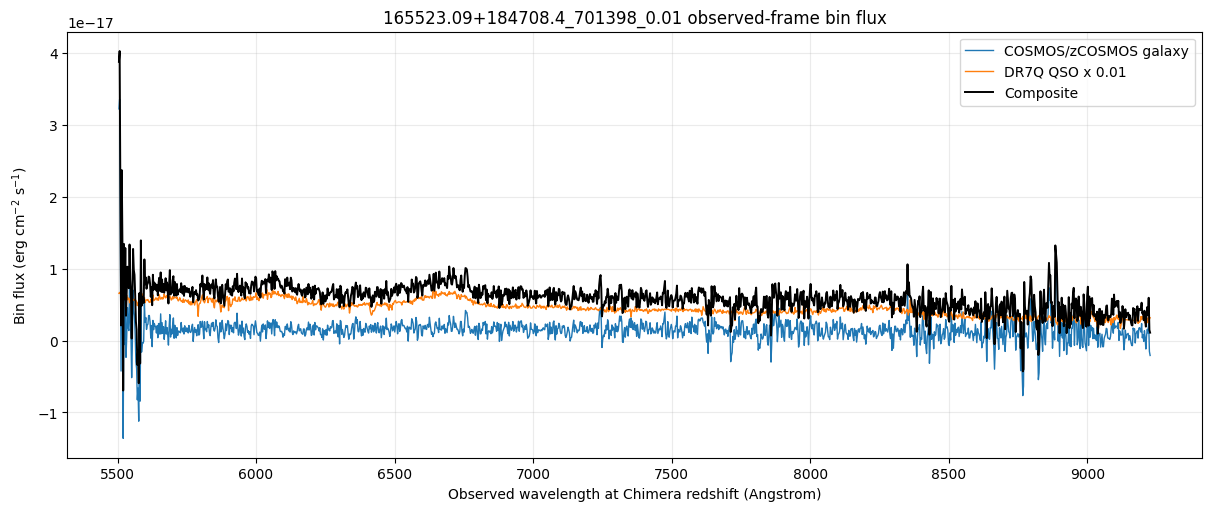

In [41]:
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
ax.plot(common_wave, galaxy_bin_flux, linewidth=1.0, label="COSMOS/zCOSMOS galaxy")
ax.plot(common_wave, weighted_qso_bin_flux, linewidth=1.0, label=f"DR7Q QSO x {qso_weight:g}")
ax.plot(common_wave, composite_bin_flux, linewidth=1.4, color="black", label="Composite")
ax.set_xlabel("Observed wavelength at Chimera redshift (Angstrom)")
ax.set_ylabel(r"Bin flux (erg cm$^{-2}$ s$^{-1}$)")
ax.set_title(f"{chimera_id} observed-frame bin flux")
ax.legend()
bin_flux_plot_path = OUTPUT_DIR / f"{safe_id}_composite_bin_flux.png"
fig.savefig(bin_flux_plot_path, dpi=180)
print(f"Wrote {bin_flux_plot_path}")
plt.show()

## Plot Observed-Frame Composite

Plot the galaxy spectrum, weighted QSO spectrum, and summed composite on the common observed-frame grid.

Wrote /home/nicho/GRAHSP/grahspj/notebook_outputs/18_chimera_composite_spectra/165523.09+184708.4_701398_0.01_composite_spectrum.png


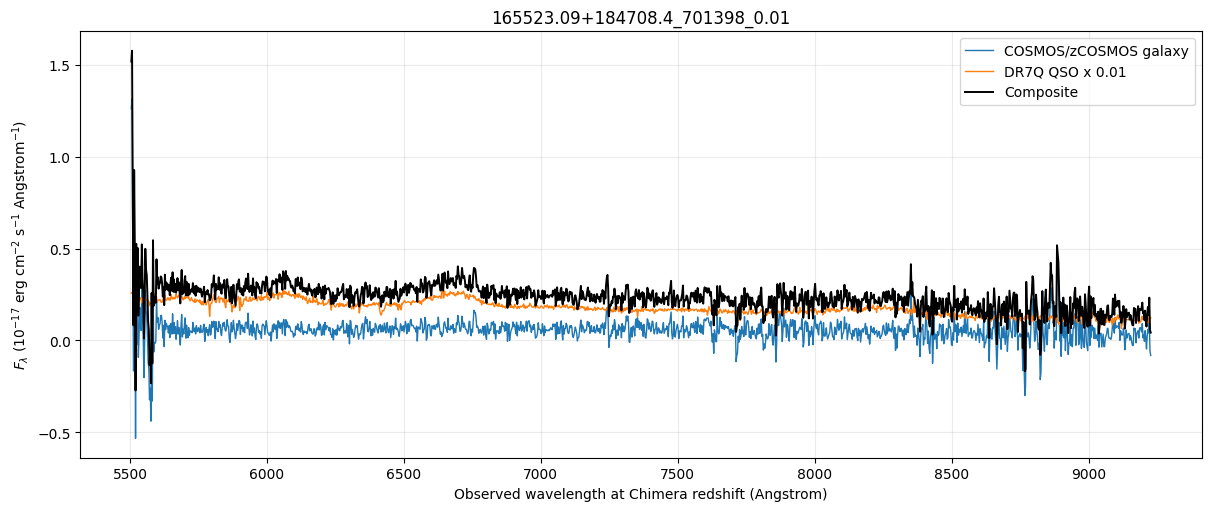

In [42]:
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
ax.plot(common_wave, galaxy_grid_flux_1e17, linewidth=1.0, label="COSMOS/zCOSMOS galaxy")
ax.plot(common_wave, weighted_qso_grid_flux_1e17, linewidth=1.0, label=f"DR7Q QSO x {qso_weight:g}")
ax.plot(common_wave, composite_flux_density_1e17, linewidth=1.4, color="black", label="Composite")
ax.set_xlabel("Observed wavelength at Chimera redshift (Angstrom)")
ax.set_ylabel(r"$F_\lambda$ (" + FLUX_DENSITY_DISPLAY_UNIT + ")")
ax.set_title(chimera_id)
ax.legend()
plot_path = OUTPUT_DIR / f"{safe_id}_composite_spectrum.png"
fig.savefig(plot_path, dpi=180)
print(f"Wrote {plot_path}")
plt.show()

## Rest-Frame Product

Optionally divide the common wavelength grid by `(1 + z_chimera)` and transform the composite flux density to rest-frame units for line identification and diagnostics.

Wrote /home/nicho/GRAHSP/grahspj/notebook_outputs/18_chimera_composite_spectra/165523.09+184708.4_701398_0.01_composite_spectrum_rest_frame.ecsv
Wrote /home/nicho/GRAHSP/grahspj/notebook_outputs/18_chimera_composite_spectra/165523.09+184708.4_701398_0.01_composite_bin_flux_rest_frame.png


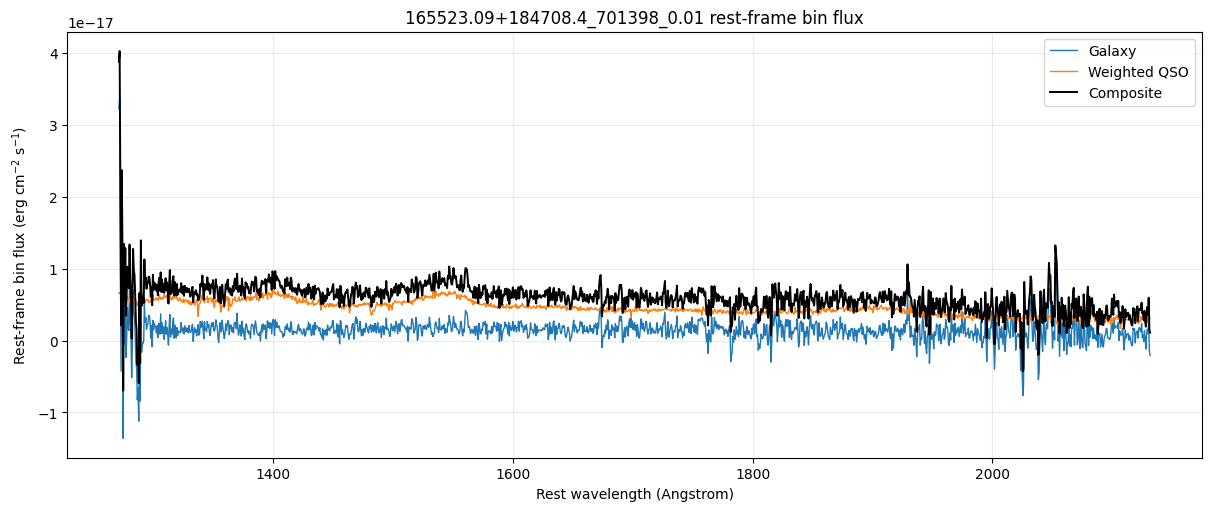

Wrote /home/nicho/GRAHSP/grahspj/notebook_outputs/18_chimera_composite_spectra/165523.09+184708.4_701398_0.01_composite_spectrum_rest_frame.png


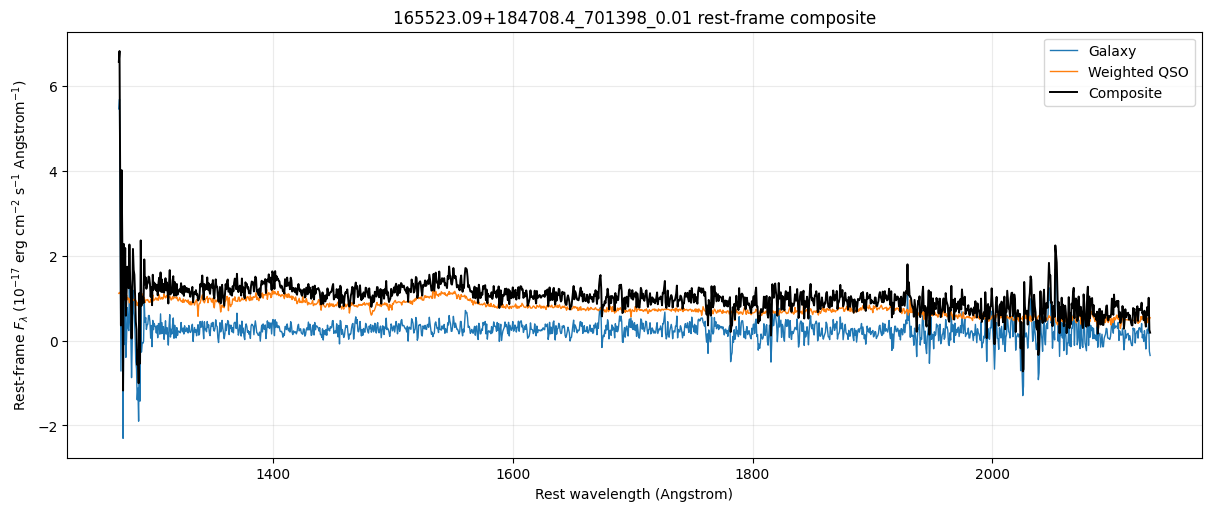

In [43]:
if MAKE_REST_FRAME_PRODUCTS:
    rest_wave = common_wave / (1.0 + chimera_redshift)
    galaxy_rest_flux = galaxy_grid_flux * (1.0 + chimera_redshift)
    weighted_qso_rest_flux = weighted_qso_grid_flux * (1.0 + chimera_redshift)
    composite_rest_flux = composite_flux_density * (1.0 + chimera_redshift)
    galaxy_rest_flux_1e17 = galaxy_rest_flux * FLUX_DENSITY_SCALE
    weighted_qso_rest_flux_1e17 = weighted_qso_rest_flux * FLUX_DENSITY_SCALE
    composite_rest_flux_1e17 = composite_rest_flux * FLUX_DENSITY_SCALE
    rest_delta_lambda = delta_lambda / (1.0 + chimera_redshift)
    galaxy_rest_bin_flux = galaxy_rest_flux * rest_delta_lambda
    weighted_qso_rest_bin_flux = weighted_qso_rest_flux * rest_delta_lambda
    composite_rest_bin_flux = composite_rest_flux * rest_delta_lambda

    rest_table = Table({
        "wavelength_rest_angstrom": rest_wave,
        "delta_lambda_rest_angstrom": rest_delta_lambda,
        "galaxy_flux_density_rest_erg_cm2_s_A": galaxy_rest_flux,
        "weighted_qso_flux_density_rest_erg_cm2_s_A": weighted_qso_rest_flux,
        "composite_flux_density_rest_erg_cm2_s_A": composite_rest_flux,
        "galaxy_flux_density_rest_1e-17_erg_cm2_s_A": galaxy_rest_flux_1e17,
        "weighted_qso_flux_density_rest_1e-17_erg_cm2_s_A": weighted_qso_rest_flux_1e17,
        "composite_flux_density_rest_1e-17_erg_cm2_s_A": composite_rest_flux_1e17,
        "galaxy_bin_flux_rest_erg_cm2_s": galaxy_rest_bin_flux,
        "weighted_qso_bin_flux_rest_erg_cm2_s": weighted_qso_rest_bin_flux,
        "composite_bin_flux_rest_erg_cm2_s": composite_rest_bin_flux,
    })
    rest_table.meta.update(metadata)
    rest_ecsv = OUTPUT_DIR / f"{safe_id}_composite_spectrum_rest_frame.ecsv"
    rest_table.write(rest_ecsv, format="ascii.ecsv", overwrite=True)
    print(f"Wrote {rest_ecsv}")

    fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
    ax.plot(rest_wave, galaxy_rest_bin_flux, linewidth=1.0, label="Galaxy")
    ax.plot(rest_wave, weighted_qso_rest_bin_flux, linewidth=1.0, label="Weighted QSO")
    ax.plot(rest_wave, composite_rest_bin_flux, linewidth=1.4, color="black", label="Composite")
    ax.set_xlabel("Rest wavelength (Angstrom)")
    ax.set_ylabel(r"Rest-frame bin flux (erg cm$^{-2}$ s$^{-1}$)")
    ax.set_title(f"{chimera_id} rest-frame bin flux")
    ax.legend()
    rest_bin_flux_plot_path = OUTPUT_DIR / f"{safe_id}_composite_bin_flux_rest_frame.png"
    fig.savefig(rest_bin_flux_plot_path, dpi=180)
    print(f"Wrote {rest_bin_flux_plot_path}")
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
    ax.plot(rest_wave, galaxy_rest_flux_1e17, linewidth=1.0, label="Galaxy")
    ax.plot(rest_wave, weighted_qso_rest_flux_1e17, linewidth=1.0, label="Weighted QSO")
    ax.plot(rest_wave, composite_rest_flux_1e17, linewidth=1.4, color="black", label="Composite")
    ax.set_xlabel("Rest wavelength (Angstrom)")
    ax.set_ylabel(r"Rest-frame $F_\lambda$ (" + FLUX_DENSITY_DISPLAY_UNIT + ")")
    ax.set_title(f"{chimera_id} rest-frame composite")
    ax.legend()
    rest_plot_path = OUTPUT_DIR / f"{safe_id}_composite_spectrum_rest_frame.png"
    fig.savefig(rest_plot_path, dpi=180)
    print(f"Wrote {rest_plot_path}")
    plt.show()
else:
    print("MAKE_REST_FRAME_PRODUCTS is False; skipped rest-frame output.")